---
title: "Lecture 1: Syllabus, Probability Axioms"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: 01_probability_axioms_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        output-file: 01_probability_axioms
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
        output-file: 01_probability_axioms
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

In [1]:
# | echo: false

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(151)
plt.rcParams["figure.figsize"] = (6, 4)

# Welcome to Math 151

Probability gives us a mathematical language for reasoning about uncertainty -- from coin flips and card games to noisy measurements and randomized algorithms. This semester we will build that language up carefully, and test it against **three running examples from randomized numerical linear algebra**: algorithms that use carefully chosen randomness to solve large linear-algebra problems. They will reappear as case studies throughout the course.

. . .

## Course logistics

Meeting Tuesdays/Thursdays 1:15-2:30pm, homework weekly via Gradescope (lowest score dropped), two in-class midterms, an in-class final, all details on the syllabus page on Canvas.

---

# Probability axioms

::: {.callout-note icon=false}
## Definition: Probability space
A **sample space** $\Omega$ is the set of all possible outcomes of an experiment. A **probability law** $P$ assigns a number $P(A)$ to each event $A \subseteq \Omega$.
:::

. . .

::: {.callout-warning icon=false}
## Theorem: Kolmogorov's Axioms
A probability law $P$ must satisfy:

1. **Non-negativity:** $P(A) \geq 0$ for every event $A$.
2. **Normalization:** $P(\Omega) = 1$.
3. **(Countable) additivity:** if $A_1, A_2, \ldots$ are disjoint, $P\left(\bigcup_i A_i\right) = \sum_i P(A_i)$.
:::

---

::: {.callout-warning icon=false}
## Fact
From the axioms alone: $P(\emptyset)=0$; $P(A^c) = 1-P(A)$; $A \subseteq B \Rightarrow P(A) \leq P(B)$; and $P(A \cup B) = P(A)+P(B)-P(A\cap B)$.
:::

## A first look: relative frequency

We haven't defined convergence yet (that's Week 7-8!), but watch what happens to the running fraction of 6's as we roll a die many times.

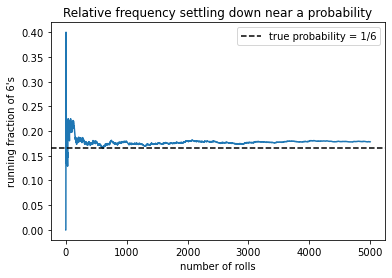

In [2]:
n_rolls = 5000
rolls = rng.integers(1, 7, size=n_rolls)
running_fraction_of_sixes = np.cumsum(rolls == 6) / np.arange(1, n_rolls + 1)

plt.plot(running_fraction_of_sixes)
plt.axhline(1/6, color="black", linestyle="--", label="true probability = 1/6")
plt.xlabel("number of rolls"); plt.ylabel("running fraction of 6's"); plt.legend()
plt.title("Relative frequency settling down near a probability")
plt.show()

---

# Sneak peek: our three running examples

- **Randomized Kaczmarz** -- an iterative solver for $Ax=b$ that samples a random row at each step, according to a carefully chosen distribution.
- **Randomized trace estimation** -- estimating $\operatorname{tr}(A)$ for a huge matrix using a handful of random matrix-vector products.
- **Randomized matrix multiplication** -- approximating a matrix product by sampling and reweighting a few columns/rows.

No linear algebra background beyond what you already have is needed -- we'll introduce exactly what's necessary each time.

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise:

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition:

:::


::: {.callout-tip icon=false}
## Note:

:::
-->